# IMPORT LIBRARY

In [17]:
import pandas as pd
import numpy as np
import torch
import re
import difflib
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
import nlpaug.augmenter.word as naw
import mlflow
import mlflow.sklearn
import dagshub

# Cek GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


# IMPORT DATASET

In [18]:
# ==========================================
# CELL 2: LOAD DATA & ROBUST CLEANING (ANTI PLIN-PLAN)
# ==========================================
import pandas as pd
import difflib

file_path = "../../data/synthetic_report_dataset.csv" 

# 1. Auto-Deteksi Pemisah Kolom
with open(file_path, 'r', encoding='utf-8') as f:
    baris_pertama = f.readline()
pemisah = '|' if '|' in baris_pertama else ','

# 2. Load Data
nama_kolom = ['teks_keluhan_awam', 'teks_laporan_teknisi', 'kategori_aset', 'severity', 'root_cause', 'tindakan']
df = pd.read_csv(file_path, sep=pemisah, names=nama_kolom, on_bad_lines='skip')

# 3. PEMBERSIHAN & PENYELAMATAN BARIS PATAH
kolom_target = ['kategori_aset', 'severity', 'root_cause', 'tindakan']
baris_patah = df[df['kategori_aset'].isna()].index

for i in baris_patah:
    if i + 1 in df.index and not pd.isna(df.loc[i+1, 'kategori_aset']):
        teks_atas = str(df.loc[i, 'teks_keluhan_awam']).strip()
        teks_bawah = str(df.loc[i+1, 'teks_keluhan_awam']).strip()
        if teks_atas != 'nan':
            df.loc[i+1, 'teks_keluhan_awam'] = teks_atas + " " + teks_bawah

df = df.dropna(subset=kolom_target)
df = df[df['teks_keluhan_awam'].astype(str).str.contains('teks_keluhan', case=False) == False]

# 4. Normalisasi Label (Robust Label Encoder)
valid_severity = ['tinggi', 'sedang', 'rendah']

def fix_label(text, valid_list):
    if pd.isna(text): return "UNKNOWN"
    clean = str(text).strip().lower()
    match = difflib.get_close_matches(clean, valid_list, n=1, cutoff=0.5)
    return match[0].capitalize() if match else "UNKNOWN"

df['severity'] = df['severity'].apply(lambda x: fix_label(x, valid_severity))
df = df[df['severity'] != 'UNKNOWN'].dropna().reset_index(drop=True)

# 5. Gabungkan Teks
df['input_teks'] = df['teks_keluhan_awam'].astype(str) + " " + df['teks_laporan_teknisi'].astype(str)

print(f"Data awal sebelum dibersihkan: {df.shape[0]} baris")

# 6. BUANG DATA PLIN-PLAN (Inconsistent Data)
# Menyimpan teks yang hanya memiliki tepat 1 label severity yang konsisten
df_bersih = df.groupby('input_teks').filter(lambda x: x['severity'].nunique() == 1)
df_bersih = df_bersih.reset_index(drop=True)

print(f"Data bersih (bebas plin-plan) siap diproses: {df_bersih.shape[0]} baris")

# 7. Siapkan X dan Y dari dataframe yang sudah bersih
Y = df_bersih[kolom_target]
X = df_bersih['input_teks']

Data awal sebelum dibersihkan: 2796 baris
Data bersih (bebas plin-plan) siap diproses: 2138 baris


# DATA AUGMENTATION

In [19]:
aug = naw.ContextualWordEmbsAug(model_path='indobenchmark/indobert-base-p1', action="substitute", device='cuda' if torch.cuda.is_available() else 'cpu')

def augment_data(text):
    try: return aug.augment(text)[0]
    except: return text

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train_aug = X_train.apply(augment_data)

X_final = pd.concat([X_train, X_train_aug])
y_final = pd.concat([y_train, y_train])

In [20]:
tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1')
bert_model = AutoModel.from_pretrained('indobenchmark/indobert-base-p1').to(device)

def get_bert_embeddings(text_list):
    bert_model.eval()
    embeddings = []
    with torch.no_grad():
        for text in text_list:
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
            outputs = bert_model(**inputs)
            # Ambil vektor [CLS] (representasi kalimat)
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb[0])
    return np.array(embeddings)

print("Mengekstrak embedding IndoBERT (mungkin butuh waktu)...")
X_train_embeddings = get_bert_embeddings(X_final.tolist())
X_test_embeddings = get_bert_embeddings(X_test.tolist())

d:\05_Personal\College\semester-6\NTG-Project\exigen-smart-maintenance\venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
d:\05_Personal\College\semester-6\NTG-Project\exigen-smart-maintenance\venv\Lib\site-packages\transformers\modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer b

Mengekstrak embedding IndoBERT (mungkin butuh waktu)...


# MODELING & TUNING

In [21]:
dagshub.init(repo_owner='NazeeraAlthea', repo_name='exigen-smart-maintenance', mlflow=True)
mlflow.set_experiment("Smart_Ticketing_Baseline_IndoBERT")

with mlflow.start_run(run_name="IndoBERT_RF_Hybrid"):
    # Karena data sudah jadi angka (embedding), kita langsung pakai Classifier
    model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))
    model.fit(X_train_embeddings, y_final)
    
    y_pred = model.predict(X_test_embeddings)
    
    # Metrik
    exact_match = (y_test.values == y_pred).all(axis=1).mean()
    mlflow.log_metric("exact_match_ratio", exact_match)
    
    print(f"Exact Match Ratio: {exact_match * 100:.2f}%")
    for i, col in enumerate(kolom_target):
        acc = accuracy_score(y_test.iloc[:, i], y_pred[:, i])
        mlflow.log_metric(f"accuracy_{col}", acc)
        print(f"Akurasi {col}: {acc * 100:.2f}%")
        
    mlflow.sklearn.log_model(model, "indobert_rf_model")

Initialized MLflow to track repo "NazeeraAlthea/exigen-smart-maintenance"

Repository NazeeraAlthea/exigen-smart-maintenance initialized!

Exact Match Ratio: 93.93%
Akurasi kategori_aset: 99.77%
Akurasi severity: 95.79%
Akurasi root_cause: 97.43%


2026/05/12 13:26:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Akurasi tindakan: 96.03%


2026/05/12 13:26:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run IndoBERT_RF_Hybrid at: https://dagshub.com/NazeeraAlthea/exigen-smart-maintenance.mlflow/#/experiments/0/runs/aefbe0569f134f419bb8de42596742c7
🧪 View experiment at: https://dagshub.com/NazeeraAlthea/exigen-smart-maintenance.mlflow/#/experiments/0


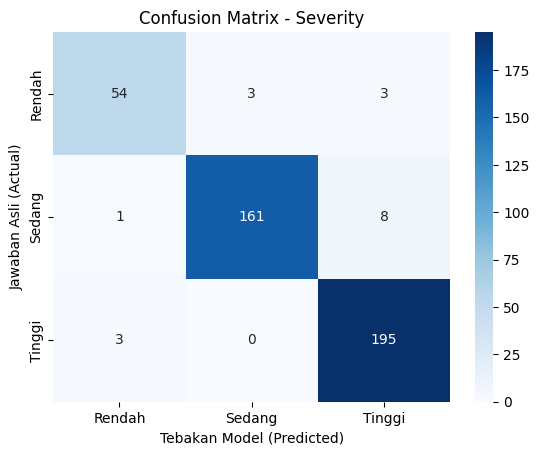

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Asumsikan indeks ke-1 adalah kolom 'severity'
y_test_sev = y_test.iloc[:, 1] 
y_pred_sev = y_pred[:, 1]

cm = confusion_matrix(y_test_sev, y_pred_sev, labels=['Rendah', 'Sedang', 'Tinggi'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rendah', 'Sedang', 'Tinggi'], yticklabels=['Rendah', 'Sedang', 'Tinggi'])
plt.ylabel('Jawaban Asli (Actual)')
plt.xlabel('Tebakan Model (Predicted)')
plt.title('Confusion Matrix - Severity')
plt.show()

In [27]:
# ==========================================
# CELL 6: INFERENCE (SIMULASI SMART TICKETING DENGAN INDOBERT)
# ==========================================
import pandas as pd
import numpy as np
import torch

# 1. Simulasi Teks Laporan Keluhan Mentah dari Frontend
teks_mentah_baru = [
    "Tolong dong AC di ruang HRD lantai 2 netes air parah sampai karpet basah semua",
    "Mesin conveyor jalur B tiba-tiba mati total dan tercium bau kabel gosong",
    "Air dari pompa utama tidak naik ke toren atap, suaranya agak kasar",
    "Lampu indikator panel listrik utama kedap-kedip terus dari pagi padahal ga diapa-apain"
]

print("=== 📥 TEKS MASUK DARI USER ===")
for i, teks in enumerate(teks_mentah_baru):
    print(f"{i+1}. {teks}")

# 2. Tahap Ekstraksi Fitur (Mengubah Teks menjadi Vektor Makna IndoBERT)
print("\n⏳ Mengekstrak makna teks menggunakan IndoBERT (Tunggu sebentar)...")
def get_inference_embeddings(text_list):
    bert_model.eval()
    embeddings = []
    with torch.no_grad():
        for text in text_list:
            # Tokenisasi kalimat baru
            inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
            # Masukkan ke "otak" IndoBERT
            outputs = bert_model(**inputs)
            # Ambil representasi vektor [CLS] (768 angka yang mewakili seluruh makna kalimat)
            emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(emb[0])
    return np.array(embeddings)

X_baru_embeddings = get_inference_embeddings(teks_mentah_baru)

# 3. Tahap Prediksi (Inference menggunakan model Random Forest Hybrid)
# Perhatikan: 'model' adalah variabel classifier kita dari Cell 5 sebelumnya
prediksi_ai = model.predict(X_baru_embeddings)

# 4. Merapikan Format Output
print("\n=== 🤖 HASIL PREDIKSI SMART TICKETING (INDOBERT) ===")
for i, hasil in enumerate(prediksi_ai):
    print(f"\nTiket #{i+1} | Teks: '{teks_mentah_baru[i]}'")
    print(f" 🔹 Kategori Aset : {hasil[0]}")
    print(f" 🔹 Severity      : {hasil[1]}")
    print(f" 🔹 Root Cause    : {hasil[2]}")
    print(f" 🔹 Tindakan      : {hasil[3]}")

=== 📥 TEKS MASUK DARI USER ===
1. Tolong dong AC di ruang HRD lantai 2 netes air parah sampai karpet basah semua
2. Mesin conveyor jalur B tiba-tiba mati total dan tercium bau kabel gosong
3. Air dari pompa utama tidak naik ke toren atap, suaranya agak kasar
4. Lampu indikator panel listrik utama kedap-kedip terus dari pagi padahal ga diapa-apain

⏳ Mengekstrak makna teks menggunakan IndoBERT (Tunggu sebentar)...

=== 🤖 HASIL PREDIKSI SMART TICKETING (INDOBERT) ===

Tiket #1 | Teks: 'Tolong dong AC di ruang HRD lantai 2 netes air parah sampai karpet basah semua'
 🔹 Kategori Aset : HVAC
 🔹 Severity      : Sedang
 🔹 Root Cause    : Tersumbat
 🔹 Tindakan      : Pembersihan

Tiket #2 | Teks: 'Mesin conveyor jalur B tiba-tiba mati total dan tercium bau kabel gosong'
 🔹 Kategori Aset : Mesin Produksi
 🔹 Severity      : Tinggi
 🔹 Root Cause    : Konsleting
 🔹 Tindakan      : Penggantian Part

Tiket #3 | Teks: 'Air dari pompa utama tidak naik ke toren atap, suaranya agak kasar'
 🔹 Kategori Ase